In [1]:
# Import TensorFlow and Keras tools for deep learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Import pretrained EfficientNetB0 model
from tensorflow.keras.applications import EfficientNetB0

# Import plotting library
import matplotlib.pyplot as plt

# Path helps manage file paths cleanly
from pathlib import Path

In [2]:
# Define dataset paths
train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

# EfficientNetB0 commonly uses 224x224 images
IMG_SIZE = (224, 224)

# Keep batch size small to avoid memory or file-loading issues
BATCH_SIZE = 8

# Seed keeps dataset split reproducible
SEED = 42

# Number of training epochs
EPOCHS = 10

In [3]:
# Load training images and split 20% for validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation images from training folder
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load testing images separately for final evaluation
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Store class names and number of classes
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 5524 files belonging to 4 classes.
Using 4420 files for training.
Found 5524 files belonging to 4 classes.
Using 1104 files for validation.
Found 554 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# AUTOTUNE lets TensorFlow optimize data loading performance
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch prepares the next batch while the model trains on the current batch
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
# Load pretrained EfficientNetB0 without its original classification layer
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers first
base_model.trainable = False

# Build final model
model = models.Sequential([
    
    # Input layer for MRI images
    layers.Input(shape=(224, 224, 3)),
    
    # EfficientNet includes its own preprocessing internally in Keras
    base_model,
    
    # Convert feature maps into one feature vector
    layers.GlobalAveragePooling2D(),
    
    # Dropout reduces overfitting
    layers.Dropout(0.3),
    
    # Output layer for MRI classes
    layers.Dense(num_classes, activation="softmax")
])

# Show model architecture
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# Configure the model for training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Train EfficientNetB0 on MRI images
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.5287 - loss: 1.0999 - val_accuracy: 0.7572 - val_loss: 0.7831
Epoch 2/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - accuracy: 0.7457 - loss: 0.7326 - val_accuracy: 0.8098 - val_loss: 0.6037
Epoch 3/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.7928 - loss: 0.6059 - val_accuracy: 0.8415 - val_loss: 0.5159
Epoch 4/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 53s 96ms/step - accuracy: 0.8109 - loss: 0.5361 - val_accuracy: 0.8551 - val_loss: 0.4620
Epoch 5/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 57s 103ms/step - accuracy: 0.8351 - loss: 0.4875 - val_accuracy: 0.8641 - val_loss: 0.4288
Epoch 6/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 62s 111ms/step - accuracy: 0.8486 - loss: 0.4550 - val_accuracy: 0.8741 - val_loss: 0.4021
Epoch 7/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 61s 111ms/step - accuracy: 0.8586 - loss: 0.4296 - val_accuracy: 0.8759 - val_loss: 0.3817
Epoch 8/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 61s 111ms/step - accuracy: 0.8638 - loss: 0.40

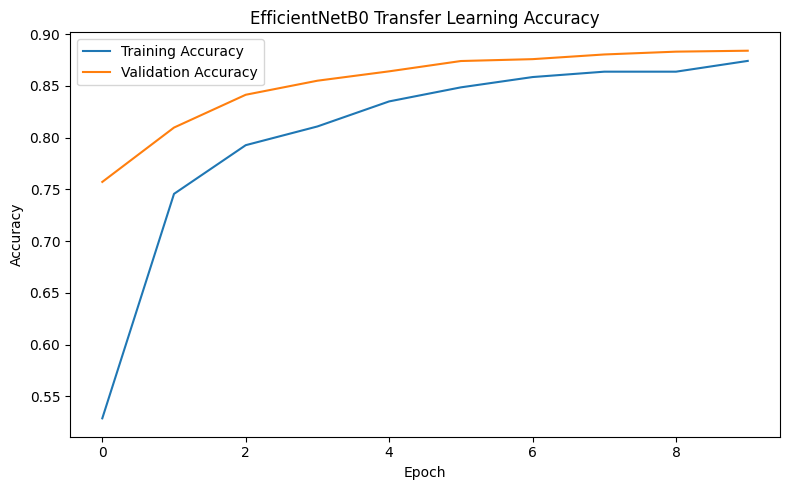

In [8]:
# Plot training and validation accuracy across epochs
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("EfficientNetB0 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/efficientnet_accuracy.png", dpi=300)
plt.show()

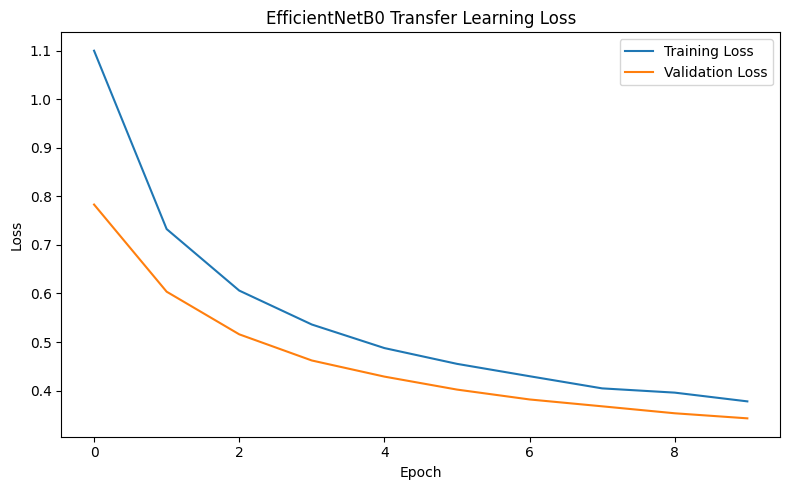

In [9]:
# Plot training and validation loss across epochs
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("EfficientNetB0 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/efficientnet_loss.png", dpi=300)
plt.show()

In [10]:
# Evaluate EfficientNetB0 on unseen testing data
test_loss, test_accuracy = model.evaluate(test_ds)

print("EfficientNetB0 Test Loss:", test_loss)
print("EfficientNetB0 Test Accuracy:", test_accuracy)

70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.8592 - loss: 0.3915
EfficientNetB0 Test Loss: 0.39154601097106934
EfficientNetB0 Test Accuracy: 0.8592057824134827


In [12]:
model.save("../models/efficientnetb0_model.keras")

## EfficientNetB0 Transfer Learning Summary

This notebook trained an EfficientNetB0 transfer learning model for multiclass brain MRI tumor classification. The pretrained EfficientNetB0 base was frozen and used as a feature extractor, while a new classification head was trained for the MRI tumor classes. This model will be compared against the baseline CNN and MobileNetV2 to evaluate whether a stronger pretrained architecture improves classification performance.
